In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

BG_COLOR = "#fdfdfdff"  

mpl.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor": BG_COLOR,
    # --- Schrift ---

    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 18,
    "axes.labelsize": 10,
    "legend.fontsize": 9,

    # --- Titel ---
    "axes.titleweight": "regular",

    # --- Achsen ---
    
    "axes.grid": False,
    "axes.linewidth": 0.4,
    "axes.spines.top": False,
    "axes.spines.right": False,

    # --- Linien ---
    "lines.linewidth": 1.2,
    "lines.solid_capstyle": "round",

    # --- Figure ---
    "figure.figsize": (8, 5),
    "figure.dpi": 120,

   
    # --- Legende ---
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.facecolor": BG_COLOR,
    "legend.edgecolor": "lightgray",
})


ENERGY_COLORS = {
    "Run-of-river hydropower": "#1f77b4",   
    "Reservoir hydropower":   "#0b3c5d",   
    "Coal":                   "#4d4d4d",   
    "Oil":                    "#8c564b",   
    "Natural gas":            "#a94442",   
    "Other fuels":            "#7f7f7f",   
    "Biogenic fuels":         "#2ca02c",   
    "Wind":                   "#17becf",  
    "Photovoltaics":          "#b6a407",  
    "Geothermal":             "#d62728",   
    "Waste":                  "#5f6d1f",
}


In [7]:
# CSV einlesen (Semikolon!)
df = pd.read_csv("Bruttostromerzeugung in Österreich ab 1950 in Gigawattstunde.csv", sep=";")


df.columns = ["year", "carrier", "value"]

translation = {
    "Laufkraftwerke": "Run-of-river hydropower",
    "Speicherkraftwerke": "Reservoir hydropower",
    "Kohle": "Coal",
    "Erdöl": "Oil",
    "Erdgas": "Natural gas",
    "Biogene Brennstoffe": "Biogenic fuels",
    "Sonstige Brennstoffe": "Other fuels",
    "Wind": "Wind",
    "Photovoltaik": "Photovoltaics",
    "Geothermie": "Geothermal"
}
df["carrier_en"] = df["carrier"].map(translation)

# Long → Wide
df_wide = df.pivot_table(
    index="year",
    columns="carrier_en",
    values="value",
    aggfunc="sum"
).fillna(0)

df_wide.head()


carrier_en,Biogenic fuels,Coal,Geothermal,Natural gas,Oil,Other fuels,Photovoltaics,Reservoir hydropower,Run-of-river hydropower,Wind
year,,,,,,,,,,
1951,0.0,1248.03,0.0,189.44,253.51,0.00,0.0,1736.59,3947.73,0.0
1952,0.0,1137.00,0.0,237.45,283.21,4.03,0.0,2103.11,4267.35,0.0
1953,0.0,1664.86,0.0,332.61,330.49,6.27,0.0,2453.38,3976.37,0.0
1954,0.0,1734.18,0.0,359.39,488.11,7.41,0.0,2433.12,4825.14,0.0
1955,0.0,1796.96,0.0,557.11,479.16,13.66,0.0,2686.91,5217.64,0.0


In [8]:
order_en = [
    "Run-of-river hydropower",
    "Reservoir hydropower",
    "Coal",
    "Oil",
    "Natural gas",
    "Other fuels",
    "Biogenic fuels",
    "Wind",
    "Photovoltaics",
    "Geothermal"
]

df_wide = df_wide[order_en]


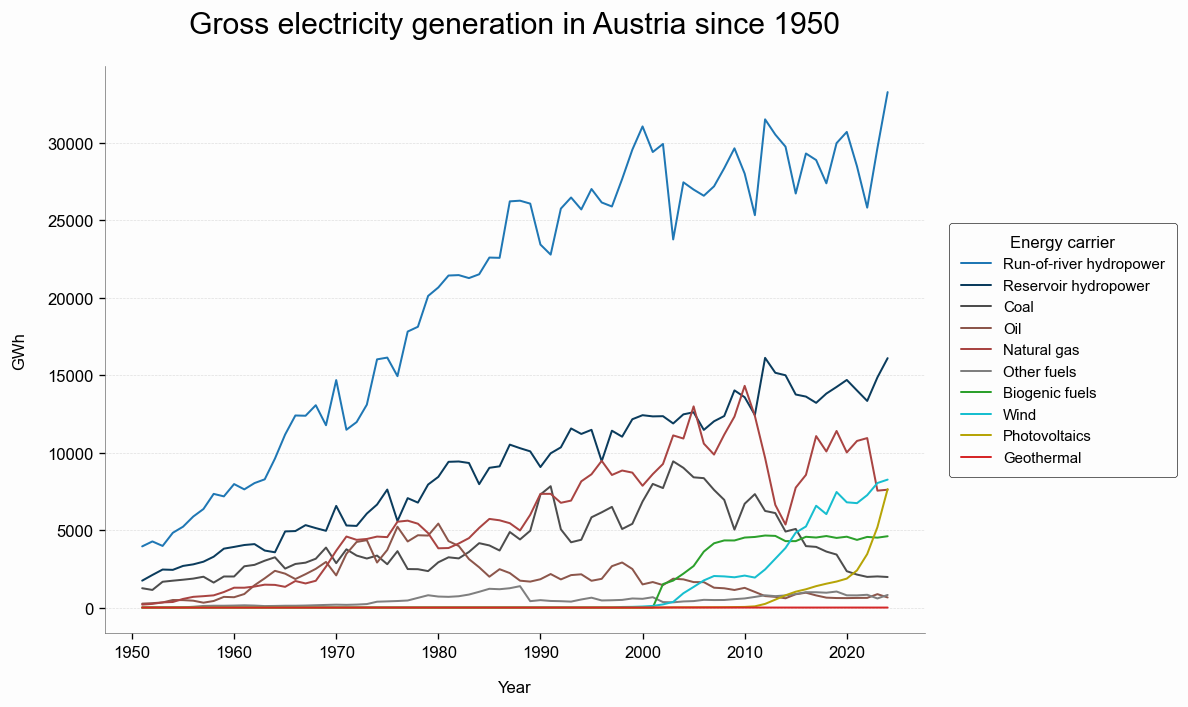

In [21]:
plt.figure(figsize=(10, 6))

for col in df_wide.columns:
    plt.plot(df_wide.index, df_wide[col], label=col, color=ENERGY_COLORS[col])

plt.title("Gross electricity generation in Austria since 1950", pad=20)
plt.xlabel("Year", labelpad=12)
plt.ylabel("GWh", labelpad=12)

plt.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.4)

legend = plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Energy carrier",
    borderpad=0.8
)

frame = legend.get_frame()
frame.set_edgecolor("black")
frame.set_linewidth(0.4)
frame.set_facecolor(BG_COLOR)

plt.subplots_adjust(right=0.78)
plt.tight_layout()
plt.savefig("Gross_electricity_gen.png")
plt.show()




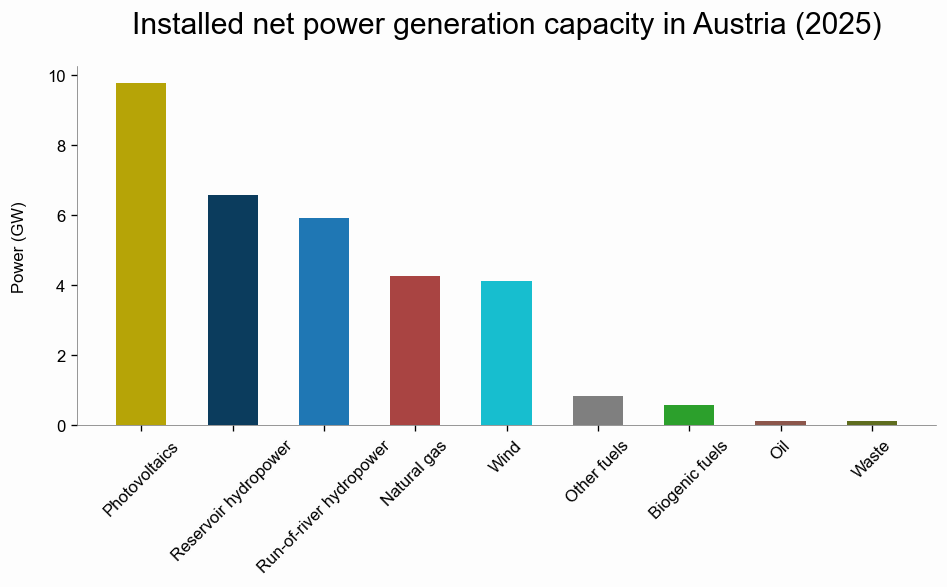

In [33]:
df_power_gen = pd.read_csv(
    "energy-charts_Installierte_Netto-Leistung_zur_Stromerzeugung_in_Österreich_in_2025.csv",
    skiprows=[1]   # überspringt die "Power (GW)"-Zeile
)

df_power_gen = df_power_gen.set_index("Jahr")
df_2025 = df_power_gen.loc[2025]

df_long = df_2025.to_frame(name="Power (GW)")
df_long = df_long.sort_values("Power (GW)", ascending=False)

fig, ax = plt.subplots()

bars = ax.bar(
    df_long.index,
    df_long["Power (GW)"],
    width=0.55,   # Standard = 0.8 → deutlich dünner
    color=[ENERGY_COLORS[col] for col in df_long.index]
)

ax.set_title(
    "Installed net power generation capacity in Austria (2025)",
    pad=20
)

ax.set_ylabel("Power (GW)", labelpad=12)
ax.set_xlabel("", labelpad=12)

ax.tick_params(axis="x", rotation=45)

ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)

plt.tight_layout()
plt.savefig("Installed_cap_power_gen_2025.png")
plt.show()
